# I. Import data & libraries

In [1]:
#data and visuals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random


#modelling
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE, SMOTENC

#automl
from auto_ml import Predictor
from auto_ml.utils import get_boston_dataset
from auto_ml.utils_models import load_ml_model

#transformed
bain_transformed = pd.read_csv("../../raw/bain_training_set_transformed.csv")
bain_transformed.columns = bain_transformed.columns.str.replace("bain_transformed_training_data.", "", 1)

#transformed with tribes
bain_transformed_withtribes = pd.read_csv("../../raw/bain_training_set_transformed_withtribes.csv")
bain_transformed_withtribes.columns = bain_transformed_withtribes.columns.str.replace("bain_training_dataset.", "", 1)

#unproccessed
bain_unprocessed = pd.read_csv("../../raw/bain_training_set_raw.csv")
bain_unprocessed.columns = bain_unprocessed.columns.str.replace("vv_bain_acxiom_match_data.", "", 1)

C:\Users\zmerritt\AppData\Local\Continuum\anaconda3\lib\site-packages\h5py\__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
print("bain_transformed", bain_transformed.shape)
print("bain_transformed_withtribes", bain_transformed_withtribes.shape)

bain_transformed (616, 257)
bain_transformed_withtribes (574, 265)


# II. Define user functions

In [3]:
#transform all survey questions into dummy and/or numerical variables for multi-regressor learning
def dumify_and_numify(df):
    """
    Purpose: convert DF into all dummy and/or numeric variables
    """
    df_clean = df
    clean_dfs = []
    for i in df.columns:

        if df[i].dtype == pd.DataFrame({"h":['e']})['h'].dtypes and i != "surveygroupid":
            l = list(df[i].fillna(''))
            l = [[word for word in row.split('|')] for row in l]

            prefix = i + "."
            cols=set(prefix + word for row in l  for word in row) #forming a set of distinct text
            if prefix in cols:
                cols.remove(prefix)

            new_df=pd.DataFrame(columns=cols)
            for row_idx in range(len(l)):
                for col in cols:
                    new_df.loc[row_idx,col]=int(col in prefix + l[row_idx][0])

            clean_dfs.append(new_df)
            if i != "Assigned Segment":
                df_clean = df_clean.drop([i], axis = 1)

    df_full = pd.concat(clean_dfs, axis = 1)
    df_full = pd.concat([df_clean, df_full], axis = 1)
    return(df_full)

# III. Clean & process data

In [90]:
#Examine duplicate IDs
print(bain_transformed.shape)
print(bain_unprocessed.shape)
print(np.unique(bain_unprocessed.surveygroupid).shape)
print(len(set(np.unique(bain_transformed.surveygroupid)) & set(np.unique(bain_unprocessed.surveygroupid))))  

#The following survey group IDs are *duplicated*
duplicateRowsDF = bain_unprocessed[bain_unprocessed.surveygroupid.isin(
    bain_unprocessed.surveygroupid[bain_unprocessed.duplicated(['customer_id'])])]
duplicateRowsDF[['customer_id','seaware_id']].sort_values('customer_id').head(2)

(616, 257)
(740, 326)
(616,)
616


,customer_id,seaware_id
595,0036A00000nQapQQAS,9475
596,0036A00000nQapQQAS,9476


In [88]:
print(np.unique(bain_unprocessed.customer_id).shape)

(614,)


In [6]:
#create single bain training data frame
keep = []
for i in bain_unprocessed.columns:
    if (i not in bain_transformed.columns and bain_unprocessed[i].dtypes != bain_unprocessed['sitename'].dtypes and
       i not in ['client_id', 'c360_id', 'dob', 'seaware_id',
                'place_placeid', 'household_household_id']) or i == 'surveygroupid':
        keep.append(i)
#I'm going to blow this up, we are doing a one-to-many join, likely on email address, which is not ideal.
#print(keep)
bain = pd.merge(bain_transformed, bain_unprocessed[keep], on = "surveygroupid", how = "inner")
print(bain.shape)
bain.head(1)

(740, 387)


,surveygroupid,surveyid,sitename,surveydate,userhostaddress,redflag,scored,q126_gender,q127_age,q131_country_of_residence,...,marketindicespopulationdemographicsage_household_underage18_percentage3to4,marketindicespopulationdemographicsage_household_underage18_percentage3to5,marketindicespopulationdemographicsage_household_underage18_percentage5,marketindicespopulationdemographicsage_household_underage18_percentage6to11,marketindicespopulationdemographicsage_household_underage18_percentage6to8,marketindicespopulationdemographicsage_household_underage18_percentage9to11,marketindicespopulationdemographicsage_household_underage18_percentunderage3,shoppingandpurchasechannel_mailorderbuyer,shoppingandpurchasechannel_mailorderdonor,shoppingandpurchasechannel_onlinepurchaseindicator
0,495554,4269555,Virgin Voyages,23:49.4,71.215.49.237:55524,0,1,Male,62,United States,...,14,16,2,23,14,9,20,True,False,True


In [7]:
#Rename columns for ease of reader interpretability
bain = bain.rename(columns = {
    "q126_gender" : "Gender", 
    "q127_age" : "Age",
    "q131_country_of_residence" : "Country of residence", 
    "q132_zip/postal_code" : "Zip code",
    "q128_marital_status" : "Marital status", 
    "q129_number_of_children_under_18" : "Number of children under 18",
    "q130_annual_household_income": "Annual household income", 
    "q50_access_url": "Access url", 
    "customer_id": "Customer id",
    "group_type": "Group type", 
    "q51_access_method" : "Access method",
    "q100" : "I always choose higher end hotels",                                                                          
    "q101" : "On vacation I pride myself on discovering new places and things my friends have not seen before",                                                                          
    "q102" : "I choose more expensive hotels and accommodations to make sure I get the best service and amenities",                                                                          
    "q103" : "It is important for me to be in a luxurious setting and to be pampered on vacation",                                                                          
    "q104" : "I like to immerse myself in the local culture when on vacation",                                                                          
    "q105" : "The difference between luxury and standard hotels just is not big enough to justify the cost",                                                                          
    "q106" : "I always pay more for a higher class of room on my vacations",                                                                          
    "q107" : "I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation",                                                                          
    "q108" : "I think spending more for unique experiences is part of what makes a vacation special",                                                                          
    "q109" : "I like to go on vacations that are off the beaten path",
    "q110" : "Have you been on a cruise in the last 10 years",
    "q111" : "Are you a planner  how far in advance do you typically book your vacations",
    "q112" : "Tell us about your most recent vacation (over 3 days)",
    "q113" : "Where do you belong  (choose up to 3)",
    "q114" : "What reeled you in  (select all that apply)",
    "q115" : "Reeled you in (comment)",
    "q116" : "What were your top 3 reasons for booking with virgin voyages",
    "q117" : "Tell us why you are excited to sail with us",
    "q118" : "Why didnt you complete your booking",
    "q119" : "Not booked (comment)",
    "q120" : "May we ask what kind of vacation you decided to go on instead",
    "q121" : "Other vacation (comment)",
    "q122" : "Are you planning to book a virgin voyage",
    "q123" : "When (are you planning to book a virgin voyage)",
    "q124" : "What is holding you back (from booking a virgin voyage)",
    "q125" : "Holding you back (comment)",
    "q200" : "Type",
    "assigned_segment" : "Assigned Segment", 
    "group" : "Group"
})   

#Identify survey questions for indepednent variable extraction
#Excluding comments
questions = [
    'I always choose higher end hotels',
    'On vacation I pride myself on discovering new places and things my friends have not seen before',
    'I choose more expensive hotels and accommodations to make sure I get the best service and amenities',
    'It is important for me to be in a luxurious setting and to be pampered on vacation',
    'I like to immerse myself in the local culture when on vacation',
    'The difference between luxury and standard hotels just is not big enough to justify the cost',
    'I always pay more for a higher class of room on my vacations',
    'I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation',
    'I think spending more for unique experiences is part of what makes a vacation special',
    'I like to go on vacations that are off the beaten path',
    'Have you been on a cruise in the last 10 years',
    'Are you a planner  how far in advance do you typically book your vacations',
    #'Tell us about your most recent vacation (over 3 days)',
    'Where do you belong  (choose up to 3)',
    'What reeled you in  (select all that apply)',
    #'Reeled you in (comment)',
    'What were your top 3 reasons for booking with virgin voyages',
    #'Tell us why you are excited to sail with us',
    #'Why didnt you complete your booking', 'Not booked (comment)',
    'May we ask what kind of vacation you decided to go on instead',
    #'Other vacation (comment)',
    'Are you planning to book a virgin voyage',
    'When (are you planning to book a virgin voyage)',
    'What is holding you back (from booking a virgin voyage)',
    #'Holding you back (comment)',
    'Assigned Segment'
]

In [8]:
#transform all survey questions into dummy and/or numerical variables for multi-regressor learning
bain_questions = bain[questions]
bain_questions_full = dumify_and_numify(bain_questions)    
bain_questions_full.head(1)

,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,I like to immerse myself in the local culture when on vacation,The difference between luxury and standard hotels just is not big enough to justify the cost,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,I think spending more for unique experiences is part of what makes a vacation special,I like to go on vacations that are off the beaten path,...,What is holding you back (from booking a virgin voyage).I don't have the time for a vacation,What is holding you back (from booking a virgin voyage).Cost of airfare,What is holding you back (from booking a virgin voyage).I want to see reviews first,What is holding you back (from booking a virgin voyage).Commitment from travel companions,Assigned Segment.Cheap + Comfy,Assigned Segment.Caviar,Assigned Segment.Cheap + Curious,Assigned Segment.Comfy,Assigned Segment.Craver,Assigned Segment.Curious
0,3,1,3,3,5,3,2,3,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
#identify Acxiom-based indepedent columns
indep_cols = []
for i in [col for col in bain.columns if col not in [
#useless or dependent columns
 "Gender", 
 "Age",
 "Country of residence", 
 "Zip code",
 "Marital status", 
 "Number of children under 18",
 "Annual household income", 
 "Access url", 
 "Customer id",
 "Group type", 
 "Access method",
 "I always choose higher end hotels",                                                                          
 "On vacation I pride myself on discovering new places and things my friends have not seen before",                                                                          
 "I choose more expensive hotels and accommodations to make sure I get the best service and amenities",                                                                          
 "It is important for me to be in a luxurious setting and to be pampered on vacation",                                                                          
 "I like to immerse myself in the local culture when on vacation",                                                                          
 "The difference between luxury and standard hotels just is not big enough to justify the cost",                                                                          
 "I always pay more for a higher class of room on my vacations",                                                                          
 "I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation",                                                                          
 "I think spending more for unique experiences is part of what makes a vacation special",                                                                          
 "I like to go on vacations that are off the beaten path",
 "Have you been on a cruise in the last 10 years",
 "Are you a planner  how far in advance do you typically book your vacations",
 "Tell us about your most recent vacation (over 3 days)",
 "Where do you belong  (choose up to 3)",
 "What reeled you in  (select all that apply)",
 "Reeled you in (comment)",
 "What were your top 3 reasons for booking with virgin voyages",
 "Tell us why you are excited to sail with us",
 "Why didnt you complete your booking",
 "Not booked (comment)",
 "May we ask what kind of vacation you decided to go on instead",
 "Other vacation (comment)",
 "Are you planning to book a virgin voyage",
 "When (are you planning to book a virgin voyage)",
 "What is holding you back (from booking a virgin voyage)",
 "Holding you back (comment)",
 "Type",
 "Assigned Segment", 
 "Group",
 "surveygroupid",
 "surveyid",
 "sitename",
 "surveydate",
 "userhostaddress",
 "redflag",
 "scored",
 "main_client_id"
]]:
    print(i)
    indep_cols.append(i)

home_video_recording_acxiom
accessories_acxiom
aerobic_acxiom
affairsandpolitics_acxiom
alcohol_wine_acxiom
american_history_acxiom
animal_welfare_acxiom
antiques_acxiom
appliances_acxiom
art_acxiom
artistic_living_acxiom
arts_antiques_acxiom
audio_books_acxiom
auto_parts_acxiom
auto_work_acxiom
automotive_acxiom
aviation_acxiom
avid_collectibles_acxiom
avid_music_listener_acxiom
baby_care_acxiom
baseball_acxiom
basketball_acxiom
beauty_cosmetics_acxiom
bestsellers_acxiom
biking_acxiom
board_games_acxiom
boating_acxiom
boatowner_acxiom
books_acxiom
broader_living_acxiom
buddhist_acxiom
budget_watchers_acxiom
cable_tv_acxiom
camping_acxiom
career_improvement_acxiom
casino_acxiom
cat_owner_acxiom
catholic_acxiom
celebrities_acxiom
charities_acxiom
children_acxiom
children_product_acxiom
children_support_financially_acxiom
chiphead_acxiom
coins_acxiom
collectibles_acxiom
collectibles_antiques_acxiom
common_living_acxiom
computer_games_acxiom
computers_acxiom
computing_acxiom
computing_hom

# IV. Create train/test sets with user defined lists

In [11]:
x_vars = bain[indep_cols]
y_vars = bain_questions_full

In [83]:
x_vars.head()

,home_video_recording_acxiom,accessories_acxiom,aerobic_acxiom,affairsandpolitics_acxiom,alcohol_wine_acxiom,american_history_acxiom,animal_welfare_acxiom,antiques_acxiom,appliances_acxiom,art_acxiom,...,marketindicespopulationdemographicsage_household_underage18_percentage3to4,marketindicespopulationdemographicsage_household_underage18_percentage3to5,marketindicespopulationdemographicsage_household_underage18_percentage5,marketindicespopulationdemographicsage_household_underage18_percentage6to11,marketindicespopulationdemographicsage_household_underage18_percentage6to8,marketindicespopulationdemographicsage_household_underage18_percentage9to11,marketindicespopulationdemographicsage_household_underage18_percentunderage3,shoppingandpurchasechannel_mailorderbuyer,shoppingandpurchasechannel_mailorderdonor,shoppingandpurchasechannel_onlinepurchaseindicator
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14,16,2,23,14,9,20,True,False,True
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,10,13,3,38,14,24,7,True,False,True
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,11,15,4,30,15,15,17,True,False,True
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,True,False,True
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,5,5,33,26,7,38,True,False,False


In [84]:
y_vars.head()

,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,I like to immerse myself in the local culture when on vacation,The difference between luxury and standard hotels just is not big enough to justify the cost,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,I think spending more for unique experiences is part of what makes a vacation special,I like to go on vacations that are off the beaten path,...,What is holding you back (from booking a virgin voyage).I don't have the time for a vacation,What is holding you back (from booking a virgin voyage).Cost of airfare,What is holding you back (from booking a virgin voyage).I want to see reviews first,What is holding you back (from booking a virgin voyage).Commitment from travel companions,Assigned Segment.Cheap + Comfy,Assigned Segment.Caviar,Assigned Segment.Cheap + Curious,Assigned Segment.Comfy,Assigned Segment.Craver,Assigned Segment.Curious
0,3,1,3,3,5,3,2,3,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,3,1,2,4,4,2,3,3,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,5,4,3,3,4,4,3,4,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,3,2,2,4,4,2,4,5,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,3,4,4,3,4,3,3,5,3,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [60]:
x_train, x_test, y_train, y_test = train_test_split(bain[indep_cols],
                                                    bain_questions_full,
                                                    test_size=0.2, random_state=195)

x_train_raw = x_train
x_test_raw = x_test

train = pd.concat([x_train, y_train["Assigned Segment"]], axis = 1)
test = pd.concat([x_test, y_test["Assigned Segment"]], axis = 1)

#fill in missing data
imp = IterativeImputer(max_iter=10, random_state=0)
imp.fit(x_train)
x_train = imp.transform(x_train)
x_test = imp.transform(x_test)

print("Shape - x_train:",x_train.shape)
print("Shape - x_test:",x_test.shape)
print("Shape - y_train:",y_train.shape)
print("Shape - y_test:",y_test.shape)

Shape - x_train: (592, 339)
Shape - x_test: (148, 339)
Shape - y_train: (592, 90)
Shape - y_test: (148, 90)


In [30]:
#user defined lists
segments = ["Cheap + Comfy","Cheap + Curious","Curious","Comfy","Craver","Caviar"]
segments2 = ["Assigned Segment." + i for i in segments]

bain_10questions = [
    'I always choose higher end hotels',
    'On vacation I pride myself on discovering new places and things my friends have not seen before',
    'I choose more expensive hotels and accommodations to make sure I get the best service and amenities',
    'It is important for me to be in a luxurious setting and to be pampered on vacation',
    'I like to immerse myself in the local culture when on vacation',
    'The difference between luxury and standard hotels just is not big enough to justify the cost',
    'I always pay more for a higher class of room on my vacations',
    'I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation',
    'I think spending more for unique experiences is part of what makes a vacation special',
    'I like to go on vacations that are off the beaten path'
]

In [25]:
#user defined functions

#Function: multi_pred_enricher
def multi_pred_enricher(preds):
    """
    Purpose: transform multi-output prediction array into dataframe with predicted Bain segment
    """
    preds = pd.DataFrame(preds)
    preds.columns = segments2
    preds = preds[segments2]
    preds['Assigned Segment'] = ""
    preds['Assigned Segment (Model Value)'] = 0
    for i in segments2:
        #Assign segment if resulting model value is the maximum resulting value
        preds.loc[:,'Assigned Segment'] = np.where(
            preds['Assigned Segment (Model Value)'] >= preds[i], preds['Assigned Segment'], i)
        preds.loc[:,'Assigned Segment (Model Value)'] = np.where(
            preds['Assigned Segment'] == i, preds[i], preds['Assigned Segment (Model Value)'])

    preds['Assigned Segment'] = preds['Assigned Segment'].map(lambda x: x.lstrip('Assigned Segment.'))   
    
    return preds

#Function: multi_pred_score_visualizer
def multi_pred_score_visualizer(preds, mod):
    #train_preds = multi_pred_enricher(mod.predict(x_train))
    #train_score = np.mean(y_train.reset_index(drop=True)['Assigned Segment'] == train_preds.reset_index(drop=True)['Assigned Segment'])
    score = np.mean(y_test.reset_index(drop=True)['Assigned Segment'] == preds)
    cm = metrics.confusion_matrix(y_test['Assigned Segment'], preds)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r'
               ,xticklabels = ["Caviar", "Cheap + Comfy","Cheap + Curious","Comfy","Craver","Curious"]
               ,yticklabels = ["Caviar", "Cheap + Comfy","Cheap + Curious","Comfy","Craver","Curious"]
               );
    plt.ylabel('Actual label');
    plt.xlabel('Predicted label');
    all_sample_title = 'Accuracy Score (test): {0}'.format(score.round(10))
    plt.suptitle(all_sample_title, size = 15);
    #plt.title('Accuracy Score (train): {0}'.format(train_score.round(10)), size = 11);
    plt.show()
    
    
def multi_feature_importance(model):
    # Plot feature importance
    feature_importance = model.feature_importances_
    # make importances relative to max importance
    feature_importance = 100.0 * (feature_importance / feature_importance.max())
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + .5
    plt.subplot(1, 2, 2)
    plt.barh(pos[-20:], feature_importance[sorted_idx][-20:], align='center')
    plt.yticks(pos[-20:], x_train_raw.columns[sorted_idx][-20:])
    plt.xlabel('Relative Importance')
    plt.title('Variable Importance')
    plt.show()

# V. Build models

## 1. Baseline models

### a. Directly predict segments

#### i. Logistic Regression

#### ii. Random guessing

In [17]:
scores = []
for i in range(100):
    guesses = []
    for i in range(x_test.shape[0]):
        rand = random.choice(segments)
        guesses.append(rand)

    score = np.mean(y_test.reset_index(drop=True)['Assigned Segment'] == np.array(guesses))
    scores.append(score)

print("Mean accuracy from randomly guessing:",np.mean(np.array(scores)))

Mean accuracy from randomly guessing: 0.17108108108108108


#### ii. Random Forrest

C:\Users\zmerritt\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


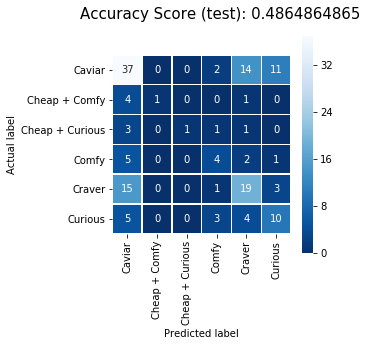

In [27]:
clf = RandomForestClassifier(random_state=195)
clf.fit(x_train, y_train['Assigned Segment'])

predictions = clf.predict(x_test)

score = clf.score(x_test, y_test['Assigned Segment'])
multi_pred_score_visualizer(predictions, clf)

### b. Predict answers to 10 Bain questions, apply segmentation key

#### i. Logistic Regression

#### ii. Random Forrest

## 3. Auto-ML

#### i. automl package, direct classification

In [46]:
from auto_ml import Predictor
column_descriptions = {
    'Assigned Segment': 'output'
}

ml_predictor = Predictor(type_of_estimator='classifier', column_descriptions=column_descriptions)

ml_predictor.train(train,verbose=True, cv=5)

ml_predictor.score(test, test['Assigned Segment'])

Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
About to fit the pipeline for the model GradientBoostingClassifier to predict Assigned Segment
Star

0.4797297297297297

#### ii. automl package, survey question classification

I always choose higher end hotels
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
About to fit the pipeline for the model GradientBoostingClassifie

I always choose higher end hotels


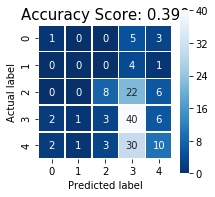

On vacation I pride myself on discovering new places and things my friends have not seen before
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
Abo

On vacation I pride myself on discovering new places and things my friends have not seen before


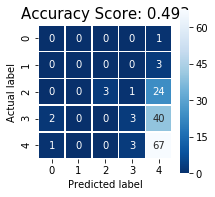

I choose more expensive hotels and accommodations to make sure I get the best service and amenities
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************

I choose more expensive hotels and accommodations to make sure I get the best service and amenities


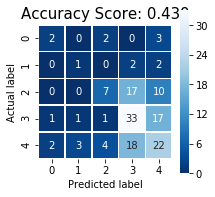

It is important for me to be in a luxurious setting and to be pampered on vacation
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
About to fit the

It is important for me to be in a luxurious setting and to be pampered on vacation


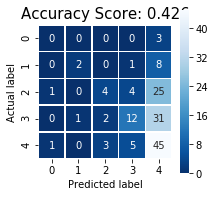

I like to immerse myself in the local culture when on vacation
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
About to fit the pipeline for the mo

I like to immerse myself in the local culture when on vacation


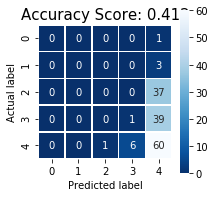

The difference between luxury and standard hotels just is not big enough to justify the cost
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
About 

The difference between luxury and standard hotels just is not big enough to justify the cost


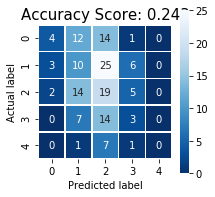

I always pay more for a higher class of room on my vacations
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
About to fit the pipeline for the mode

I always pay more for a higher class of room on my vacations


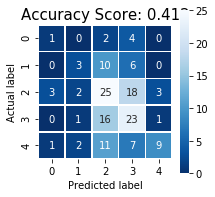

I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


***********************************************************************

I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation


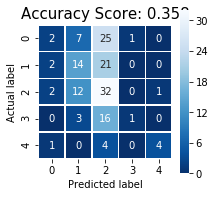

I think spending more for unique experiences is part of what makes a vacation special
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
About to fit 

I think spending more for unique experiences is part of what makes a vacation special


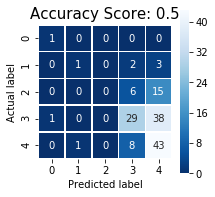

I like to go on vacations that are off the beaten path
Welcome to auto_ml! We're about to go through and make sense of your data using machine learning, and give you a production-ready pipeline to get predictions with.

If you have any issues, or new feature ideas, let us know at http://auto.ml
You are running on version 2.9.9
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}
Running basic data cleaning
Fitting DataFrameVectorizer
Now using the model training_params that you passed in:
{}
After overwriting our defaults with your values, here are the final params that will be used to initialize the model:
{'presort': False, 'learning_rate': 0.1, 'warm_start': True}


********************************************************************************************
About to fit the pipeline for the model Grad

I like to go on vacations that are off the beaten path


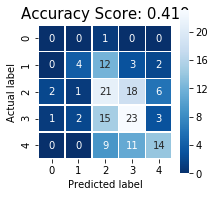

In [63]:
#make predictions for each question, store probability for every class (1-5)
#storage lists:
question_test_preds = []
question_test_pred_probas = []
question_train_pred_probas = []
question_test_scores = []

#loop through questions and make predictions, output results
for i in bain_10questions:
    #model
    # all parameters not specified are set to their defaults
    print(i)
    
    train = pd.concat([x_train_raw, y_train[[i]]], axis = 1)
    test = pd.concat([x_test_raw, y_test[[i]]], axis = 1)
    
    column_descriptions = {
        i: 'output'
    }

    ml_predictor = Predictor(type_of_estimator='classifier', column_descriptions=column_descriptions)

    ml_predictor.train(train,verbose=True, cv=5)
    test_predictions = ml_predictor.predict(test)
    train_prediction_probas = ml_predictor.predict_proba(train)
    test_prediction_probas = ml_predictor.predict_proba(test)
    # Use score method to get accuracy of model
    test_score = ml_predictor.score(test, test[i])
    
    #append
    question_test_preds.append(test_predictions)
    question_test_scores.append(test_score)
    
    question_test_pred_probas.append(test_prediction_probas)
    question_train_pred_probas.append(train_prediction_probas)
    
    #print results
    print(i)
    cm = metrics.confusion_matrix(y_test[i], test_predictions)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
    plt.ylabel('Actual label');
    plt.xlabel('Predicted label');
    all_sample_title = 'Accuracy Score: {0}'.format(test_score.round(3))
    plt.title(all_sample_title, size = 15)
    plt.show()

In [64]:
#load .py file
import sys
sys.path.append('../../progs/')
import bain_response_enrich as bre
def list_array_todf(list_array, column_names):
    df = list_array.copy()
    for i in range(len(list_array)):
        df[i] = list_array[i]
    df = pd.DataFrame(df).T
    df.columns = column_names
    return df

question_test_preds_df = list_array_todf(question_test_preds, bain_10questions)
question_test_preds_df_assigned = bre.bain_response_enrich(question_test_preds_df)
question_test_preds_df_assigned.head()

,I always choose higher end hotels,On vacation I pride myself on discovering new places and things my friends have not seen before,I choose more expensive hotels and accommodations to make sure I get the best service and amenities,It is important for me to be in a luxurious setting and to be pampered on vacation,I like to immerse myself in the local culture when on vacation,The difference between luxury and standard hotels just is not big enough to justify the cost,I always pay more for a higher class of room on my vacations,I would rather spend as little as possible on accommodations so I have more money to spend on other parts of my vacation,I think spending more for unique experiences is part of what makes a vacation special,I like to go on vacations that are off the beaten path,Assigned Segment,Assigned Segment (Model Value),Cheap + Comfy,Cheap + Curious,Curious,Comfy,Craver,Caviar
0,4,4,1,3,5,3,1,5,4,3,Curious,62.223,59.773,61.751,62.223,58.461,55.578,50.929
1,4,5,4,5,5,3,3,2,5,3,Craver,92.016,73.997,72.206,86.677,85.428,92.016,90.539
2,4,5,4,5,5,3,3,3,5,4,Craver,97.930,78.859,78.614,92.414,90.122,97.930,94.543
3,5,5,3,4,5,3,3,2,5,2,Craver,85.189,70.646,68.618,81.509,80.317,85.189,84.148
4,4,5,5,5,5,3,4,3,5,4,Craver,108.293,83.821,82.267,99.608,98.452,108.293,105.408


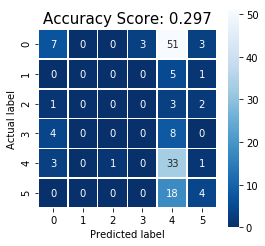

In [65]:
score = np.mean(y_test.reset_index(drop=True)['Assigned Segment'] == question_test_preds_df_assigned.reset_index(drop=True)['Assigned Segment'])
cm = metrics.confusion_matrix(y_test['Assigned Segment'], question_test_preds_df_assigned['Assigned Segment'])
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score.round(3))
plt.title(all_sample_title, size = 15);

## 2. Multi-Output Regressor

In [69]:
x_train, x_test, y_train, y_test = train_test_split(bain[indep_cols],
                                                    bain_questions_full,
                                                    test_size=0.2, random_state=195)
imp = IterativeImputer(max_iter=10, random_state=0)
imp.fit(x_train)
x_train = imp.transform(x_train)
x_test = imp.transform(x_test)

#### a. Directly predicted segments

C:\Users\zmerritt\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


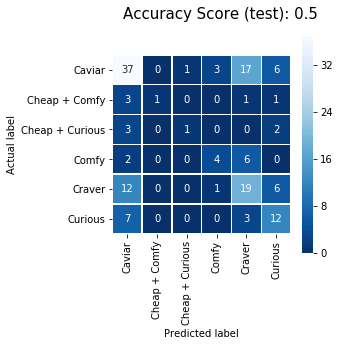

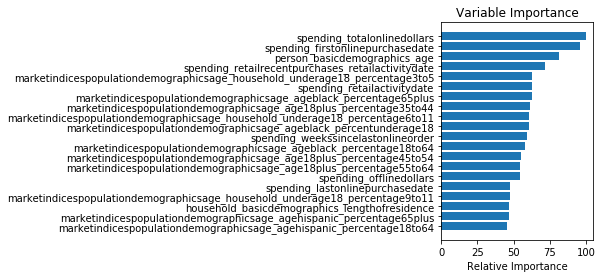

In [73]:
#Random forrest regressor
regr_rf = RandomForestRegressor(random_state=195)
regr_rf.fit(x_train, y_train[segments2])
# Predict on new data
y_rf = regr_rf.predict(x_test)
y_rf = multi_pred_enricher(y_rf)
y_rf = np.array(y_rf['Assigned Segment'])
multi_pred_score_visualizer(y_rf, regr_rf)
multi_feature_importance(regr_rf)

In [ ]:
n_estimatorss = [300, 400, 500, 1000]
max_depths = [15, 25]
min_samples_leafs = [2]
penaltys = ['l2']
Cs = [.1, .5]

scoresX = []
n_estimatorssX = []
max_depthsX = []
min_samples_leafsX = []
penaltysX = []
CsX = []
randsX = []

a = 0
score_master = 0
for n_estimators in n_estimatorss:
    for max_depth in max_depths:
        for min_samples_leaf in min_samples_leafs:
            #Logistic regression
            for penalty in penaltys:
                for C in Cs:
                    a += 1
                    print(a)
                    
                    for i in range(4):
                        rand = a * i
                        
                        #Train/test split
                        x_train, x_test, y_train, y_test = train_test_split(bain[indep_cols],
                                                    bain_questions_full,
                                                    test_size=0.2, random_state=rand)

                        imp = IterativeImputer(max_iter=10, random_state=0)
                        imp.fit(x_train_raw)
                        x_train = imp.transform(x_train)
                        x_test = imp.transform(x_test)

                        
                        regr_rf_1 = RandomForestRegressor(
                            n_estimators=n_estimators,
                            max_depth=max_depth,
                            min_samples_leaf = min_samples_leaf,
                            random_state=rand)

                        regr_rf_1.fit(x_train, y_train[segments2])
                        # Predict on new data
                        y_rf = regr_rf_1.predict(x_test)

                        regr_rf = LogisticRegression(
                            random_state = rand, 
                            penalty = penalty,
                            C = C,
                            multi_class = 'ovr')

                        regr_rf.fit(regr_rf_1.predict(x_train), y_train['Assigned Segment'])
                        # Predict on new data
                        y_rf = regr_rf.predict(regr_rf_1.predict(x_test))
                        
                        score = np.mean(y_rf == y_test['Assigned Segment'])
                        if score > score_master:
                            score_master = score
                            print("NEW WINNER")
                        print("--", score_master)
                        
                        scoresX.append(score)
                        n_estimatorssX.append(n_estimators)
                        max_depthsX.append(max_depth)
                        min_samples_leafsX.append(min_samples_leaf)
                        penaltysX.append(penalty)
                        CsX.append(C)
                        randsX.append(rand)
                        
results = pd.DataFrame({
    'score':scoresX,
    'n_estimators':n_estimatorssX,
    'max_depth':max_depthsX,
    'min_samples_leaf':min_samples_leafsX,
    'penalty':penaltysX,
    'C':CsX,
    'rand':randsX
})

In [74]:
results = pd.read_csv("cv_approx1.csv")

In [78]:
results.drop(['rand','Unnamed: 0'],axis = 1).sort_values(
    by=['score'], ascending =False).head(20)

,score,n_estimators,max_depth,min_samples_leaf,penalty,C
259,0.594595,200,25,1,l2,1.0
215,0.581081,200,15,1,l2,1.5
193,0.574324,200,15,1,l1,0.5
257,0.574324,200,25,1,l2,1.0
287,0.567568,200,25,2,l2,1.5
182,0.567568,150,25,2,l2,0.5
234,0.567568,200,15,2,l2,1.0
245,0.560811,200,25,1,l1,1.0
165,0.560811,150,25,1,l2,1.5
278,0.560811,200,25,2,l2,0.5


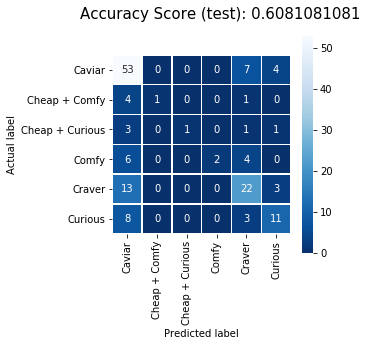

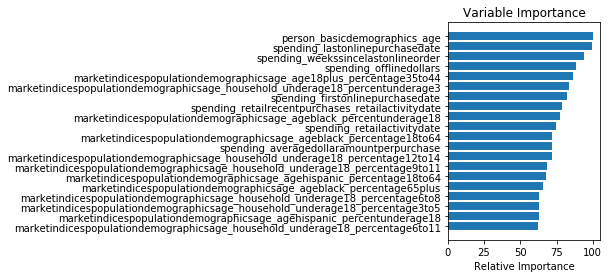

In [82]:
#Random forrest regressor
regr_rf = RandomForestRegressor(n_estimators=200, 
                                max_depth=25,
                                min_samples_leaf = 1,
                                random_state=195)
regr_rf.fit(x_train, y_train[segments2])
# Predict on new data
y_rf = regr_rf.predict(x_test)
y_rf = multi_pred_enricher(y_rf)
y_rf = np.array(y_rf['Assigned Segment'])
multi_pred_score_visualizer(y_rf, regr_rf)
multi_feature_importance(regr_rf)

In [94]:
#FIX THIS train.spending_lastonlinepurchasedate

624           NaN
168           NaN
715    20171210.0
132    20180131.0
581    20161211.0
412    20180624.0
213    20090909.0
118    20150105.0
548           NaN
388    20180303.0
737           NaN
27            NaN
507    20161101.0
642    20180607.0
536    20160904.0
30            NaN
234    20160325.0
687    20161212.0
569    20180526.0
696           NaN
450    20161127.0
113    20160828.0
358    20141218.0
577    20180702.0
278    20160914.0
233           NaN
583    20170510.0
265           NaN
339    20171212.0
399           NaN
          ...    
382           NaN
253    20180213.0
276           NaN
79     20140506.0
376    20160321.0
355    20141118.0
121    20160425.0
451           NaN
632    20171014.0
390    20171218.0
375    20150814.0
678    20170525.0
586    20180928.0
124    20140826.0
720           NaN
684    20171230.0
219    20141127.0
142    20170505.0
228           NaN
707    20170902.0
369           NaN
467    20180127.0
304    20170114.0
61     20180618.0
21        

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
#Random forrest regressor

steps = [
   ('scalar', StandardScaler()),
   # ('poly', PolynomialFeatures(degree=2)),
    ('model', Lasso(alpha=0.3, fit_intercept=True))
]

regr_rf = Pipeline(steps)

regr_rf.fit(x_train, y_train[segments2])
# Predict on new data
y_rf = regr_rf.predict(x_test)
y_rf = multi_pred_enricher(y_rf)
multi_pred_score_visualizer(y_rf, regr_rf,
                           x_train = x_train, x_test = x_test,
                           y_train = y_train, y_test = y_test)
multi_feature_importance(regr_rf)

In [ ]:
#SMOTE Oversampling
sm = SMOTE(random_state=12, sampling_strategy = 'auto', k_neighbors = 12)
x_train_res, y_train_res = sm.fit_sample(x_train, y_train["Assigned Segment"])
y_train_resdf = pd.DataFrame(y_train_res)
y_train_resdf.columns = ["Assigned Segment"]
print(y_train_resdf["Assigned Segment"].value_counts())
y_train_resdf_conv = dumify_and_numify(y_train_resdf)


#Random forrest regressor
regr_rf = RandomForestRegressor(n_estimators=150, 
                                max_depth=25,
                                random_state=2)
regr_rf.fit(x_train_res, y_train_resdf_conv[segments2])
# Predict on new data
y_rf = regr_rf.predict(x_test)
y_rf = multi_pred_enricher(y_rf)
multi_pred_score_visualizer(y_rf, regr_rf,
                           x_train = x_train_res, x_test = x_test,
                           y_train = y_train_resdf_conv, y_test = y_test)
multi_feature_importance(regr_rf)

In [ ]:
#Gradient Boosting regressor
regr_gb = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=100, 
    max_depth=30,
    random_state=2))
regr_gb.fit(x_train, y_train[segments2])
# Predict on new data
y_gb = regr_gb.predict(x_test)
y_gb = multi_pred_enricher(y_gb)
multi_pred_score_visualizer(y_gb, regr_gb,
                           x_train = x_train, x_test = x_test,
                           y_train = y_train, y_test = y_test)

In [ ]:
#bagging regressor
regr_bag = MultiOutputRegressor(BaggingRegressor(
    n_estimators=100, 
    random_state=2))
regr_bag.fit(x_train, y_train[segments2])
# Predict on new data
y_bag = regr_bag.predict(x_test)
y_bag = multi_pred_enricher(y_bag)
multi_pred_score_visualizer(y_bag, regr_bag,
                           x_train = x_train, x_test = x_test,
                           y_train = y_train, y_test = y_test)

#### b. Predict answers to 10 Bain questions, apply segmentation key

In [ ]:
#Random forrest regressor WITH feature selection

feat_selector = RandomForestRegressor(n_estimators=150, 
                                max_depth=25,
                                #min_samples_leaf = 10,
                                random_state=2)
feat_selector.fit(x_train, y_train[segments2])
# Create a selector object that will use the random forest classifier to identify
# features that have an importance of more than 0.15
sfm = SelectFromModel(feat_selector, threshold=0.01)

# Train the selector
sfm.fit(x_train, y_train[segments2])

x_important_train = sfm.transform(x_train)
x_important_test = sfm.transform(x_test)

print("# of features selected:", x_important_train.shape[1])
regr_rf = RandomForestRegressor(n_estimators=150, 
                                max_depth=25,
                                #min_samples_leaf = 10,
                                random_state=2)
regr_rf.fit(x_important_train, y_train[segments2])
# Predict on new data
y_rf = regr_rf.predict(x_important_test)
y_rf = multi_pred_enricher(y_rf)
multi_pred_score_visualizer(y_rf, mod = regr_rf, 
                            x_train = x_important_train, x_test = x_important_test,
                           y_train = y_train, y_test = y_test)
multi_feature_importance(regr_rf)

In [ ]:
regr_rf = RandomForestRegressor(random_state=2)
#regr_rf.fit(x_train, y_train[segments2])

param_grid = { 
    'n_estimators': [10, 100],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [10,30,50],
    #'criterion': ['mse','mae'],
    #'verbose': [0,1],
    #'max_depth': [10,30,50,100]
}

CV_rfc = GridSearchCV(estimator=regr_rf, param_grid=param_grid, cv= 5)
CV_rfc.fit(x_train, y_train[segments2])
print(CV_rfc.best_params_)

In [ ]:
x_train.head()

In [ ]:
from auto_ml import Predictor
from auto_ml.utils import get_boston_dataset
from auto_ml.utils_models import load_ml_model
x_train, x_test, y_train, y_test = train_test_split(bain[indep_cols],
                                                    bain_questions_full,
                                                    test_size=0.2, random_state=0)

#imp = IterativeImputer(max_iter=10, random_state=0)
#imp.fit(x_train_raw)
#x_train = imp.transform(x_train_raw)
#x_test = imp.transform(x_test)

print("Shape - x_train:",x_train.shape)
print("Shape - x_test:",x_test.shape)
print("Shape - y_train:",y_train.shape)
print("Shape - y_test:",y_test.shape)


train = pd.concat([x_train, y_train[segments2]], axis = 1)
test = pd.concat([x_test, y_test[segments2]], axis = 1)

In [ ]:
#make predictions for each question, store probability for every class (1-5)


#storage lists:
question_test_preds = []
question_test_pred_probas = []
question_train_pred_probas = []
question_test_scores = []

#loop through questions and make predictions, output results
for i in segments2:
    #model
    # all parameters not specified are set to their defaults
    print(i)
    
    train = pd.concat([x_train, y_train[[i]]], axis = 1)
    test = pd.concat([x_test, y_test[[i]]], axis = 1)
    
    column_descriptions = {
        i: 'output'
    }

    ml_predictor = Predictor(type_of_estimator='classifier', column_descriptions=column_descriptions)

    ml_predictor.train(train,verbose=True, cv=5)
    test_predictions = ml_predictor.predict(test)
    train_prediction_probas = ml_predictor.predict_proba(train)
    test_prediction_probas = ml_predictor.predict_proba(test)
    # Use score method to get accuracy of model
    test_score = ml_predictor.score(test, test[i])
    
    #append
    question_test_preds.append(test_predictions)
    question_test_scores.append(test_score)
    
    question_test_pred_probas.append(test_prediction_probas)
    question_train_pred_probas.append(train_prediction_probas)
    
    #print results
    print(i)
    cm = metrics.confusion_matrix(y_test[i], test_predictions)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
    plt.ylabel('Actual label');
    plt.xlabel('Predicted label');
    all_sample_title = 'Accuracy Score: {0}'.format(test_score.round(3))
    plt.title(all_sample_title, size = 15)
    plt.show()

#Final accuracy by question


In [ ]:
#import 
sns.barplot(y = segments, x = question_test_scores).set(xlabel='Accuracy');

probas = []
for i in range(len(segments)):
    seg = segments[i]
    df = pd.DataFrame(question_train_pred_probas[i]).iloc[:,1]
    #df.columns = seg
    probas.append(df)
    
proba_df = pd.concat(probas, axis = 1)
proba_df.columns = segments
#proba_df.head()
train_down = proba_df

probas = []
for i in range(len(segments)):
    seg = segments[i]
    df = pd.DataFrame(question_test_pred_probas[i]).iloc[:,1]
    #df.columns = seg
    probas.append(df)
    
proba_df = pd.concat(probas, axis = 1)
proba_df.columns = segments
test_down = proba_df

preds = multi_pred_enricher(proba_df)
np.mean(preds.reset_index()['Assigned Segment'] == y_test.reset_index()['Assigned Segment'])

In [ ]:
#Random forrest regressor
regr_rf = RandomForestRegressor(n_estimators=150, 
                                max_depth=25,
                                random_state=2)
regr_rf.fit(train_down, y_train[segments2])
# Predict on new data
y_rf = regr_rf.predict(test_down)
y_rf = multi_pred_enricher(y_rf)
multi_pred_score_visualizer(y_rf, regr_rf,
                           x_train = train_down, x_test = test_down,
                           y_train = y_train, y_test = y_test)
multi_feature_importance(regr_rf)

In [ ]:
#Random forrest regressor
regr_rf = RandomForestClassifier(n_estimators=150, 
                                max_depth=25,
                                random_state=2)
regr_rf.fit(train_down, y_train["Assigned Segment"])
# Predict on new data
y_rf = regr_rf.predict(test_down)
#y_rf = multi_pred_enricher(y_rf)
np.mean(y_rf == y_test.reset_index()['Assigned Segment'])